In [ ]:
#import all libraries

from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import pandas as po
import math
from sklearn import metrics
from sklearn.metrics import confusion_matrix
num_points=0.0

# Binary Classifier Evaluator

## File I/O

In [ ]:
#upload test labels and team's predictions
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving team1_binary.pkl to team1_binary (1).pkl
User uploaded file "team1_binary (1).pkl" with length 24301 bytes


In [ ]:
#format of team pkl file
#   prediction	proba_x	  proba_y
# 0	1	          0.356353	0.643647
# 1	0	          0.999149	0.000851
# 2	0           0.951637	0.048363
# 3 1         	1.000000	0.000000
# 4	            1.000000	0.000000
#etc..

Group_Predictions=po.DataFrame(po.read_pickle('/content/team1_binary.pkl')) #from student submission
Group_Predictions=Group_Predictions.apply(po.to_numeric)
Group_Predictions

,prediction,proba_x,proba_y
0,0.0,1.0,0.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0
...,...,...,...
967,0.0,1.0,0.0
968,0.0,1.0,0.0
969,0.0,1.0,0.0
970,0.0,1.0,0.0


In [ ]:
#upload test data answers
all_test_labels=po.read_pickle("hypothyroid_binary_test_labels.pkl") #from GitHub
all_test_labels["class"]=po.get_dummies(all_test_labels["class"],drop_first=True)

In [ ]:
#for if the group omitted rows
required_testing_labels=po.DataFrame()
for i in Group_Predictions.index:
  required_testing_labels=po.concat([required_testing_labels, all_test_labels.iloc[i]])
len(required_testing_labels)

972

In [ ]:
np.array(required_testing_labels).reshape(1, -1)[0].astype(int)

## Binary Confusion Matrix

In [ ]:
# This is exactly the first metric you'll be evaluated on!
# Note: this will only work on the binary case -- let us know if you get to the multi-class case
def cm_metric(y_true,y_val_predict):
    # predict the class with the greatest probability
    #y_val_predict = [np.argmax(y) for y in y_prob]
    # calculate the confusion matrix
    cm = confusion_matrix(y_true, y_val_predict)
    print(cm)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    return sum(sum(np.multiply(cm_norm,np.array([[1, -4], [-4, 1]]))))

#cm_metric(required_testing_labels,Group_Predictions.values)

num_points+=cm_metric(required_testing_labels,Group_Predictions.values[:,0]) #max is 2

[[892   9]
 [ 19  52]]


In [ ]:
####
fpr, tpr, threshold = metrics.roc_curve(required_testing_labels, Group_Predictions.values[:,0])
roc_auc = metrics.auc(fpr, tpr)
roc_auc

0.8612027324881587

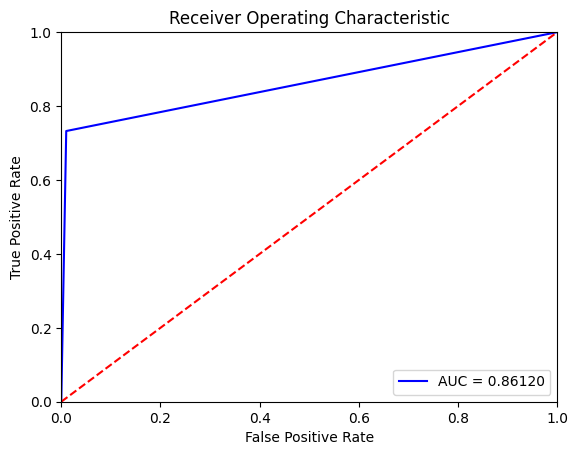

[[892   9]
 [ 19  52]]
0.6120273248815871
AUC:  0.8612027324881587
Score:  2.9464601147394918


In [ ]:
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.5f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()
print(cm_metric(required_testing_labels,Group_Predictions.values[:,0]))
print("AUC: ",roc_auc)
num_points += roc_auc
print("Score: ",str(num_points)) #MAX score: (2+1)=3 points

# Multiclass Classifier Evaluator

In [ ]:
#upload test labels and team's predictions
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving team6_week1_multi.pkl to team6_week1_multi.pkl
User uploaded file "team6_week1_multi.pkl" with length 31995 bytes


In [ ]:
#reading in the Group_Predictions as a data frame
Group_Predictions=po.DataFrame(po.read_pickle('/content/team6_week1_multi.pkl')) #from student submission
Group_Predictions=Group_Predictions.apply(po.to_numeric)
# print(Group_Predictions.shape)
# Group_Predictions = Group_Predictions[Group_Predictions.iloc[:, 0] != 3]
# Group_Predictions.head(20)

In [ ]:
Group_Predictions.shape[1] == 4

True

In [ ]:
all_test_labels.value_counts()

class
0        901
1         40
2         31
dtype: int64

In [ ]:
all_test_labels=po.read_pickle("hypothyroid_multiclass_test_labels.pkl") #from github
# all_test_labels["class"]=po.get_dummies(all_test_labels,drop_first=True)
all_test_labels
#Fixing the class variables
# all_test_labels['class'] = all_test_labels['class'].replace('negative', 0)
# all_test_labels['class'] = all_test_labels['class'].replace('compensated hypothyroid', 1)
# all_test_labels['class'] = all_test_labels['class'].replace('primary hypothyroid', 2)
# all_test_labels['class'] = all_test_labels['class'].replace('secondary hypothyroid', 3)

,class
0,0
1,0
2,0
3,0
4,0
...,...
967,0
968,0
969,0
970,0


In [ ]:
#Create a data frame of testing labels that correspond to the indices that the students used (the students may have omitted rows)
required_testing_labels=po.DataFrame()
for i in Group_Predictions.index:
  required_testing_labels=po.concat([required_testing_labels, all_test_labels.iloc[i]])

In [ ]:
required_testing_labels

,0
class,0.0
class,0.0
class,0.0
class,0.0
class,0.0
...,...
class,0.0
class,0.0
class,0.0
class,0.0


In [ ]:
def cm_metric_complex(y_true,y_prob):
    # predict the class with the greatest probability
    # y_val_predict = [np.argmax(y) for y in y_prob]
    # calculate the confusion matrix
    cm = confusion_matrix(y_true, y_prob)
    print(cm)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print(cm_norm)
    return sum(sum(np.multiply(cm_norm,np.array([[1, -1,-2],
                                                 [-4, 2,-1],
                                                 [-8, -4,3]])))) #3 x 3 because 1 class value is so rare

#Argument 1 data type: pandas.DataFrame (of test labels) // Argument 2 data type: numpy.ndarray  (of the team's predictions)
num_points+=cm_metric_complex(required_testing_labels, Group_Predictions.iloc[:,0])

[[899   1   1]
 [  0  40   0]
 [  1   0  30]]
[[0.99778024 0.00110988 0.00110988]
 [0.         1.         0.        ]
 [0.03225806 0.         0.96774194]]


In [ ]:
#compiling the 1 multiclass class feature into 3 columns (one hot encoding))
#this puts the test labels into a format appropriate for computing the roc_curve function
one_hot_test_labels=po.get_dummies(po.get_dummies(np.array(required_testing_labels).reshape(1, -1)[0]))
one_hot_group_predictions = po.get_dummies(Group_Predictions.iloc[:, 0])

one_hot_test_labels

,0.0,1.0,2.0
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
967,1,0,0
968,1,0,0
969,1,0,0
970,1,0,0


In [ ]:
# one_hot_group_predictions['2'] = 0
one_hot_group_predictions

,0,1,2
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
967,1,0,0
968,1,0,0
969,1,0,0
970,1,0,0


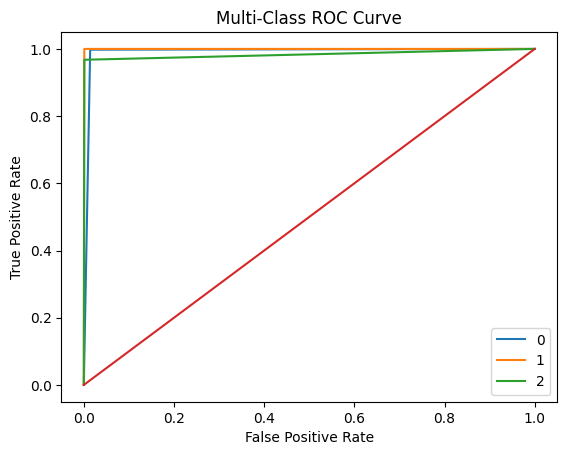

0.9976851851851851

In [ ]:
#computing AUROC using a macro-type calculation
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
  fpr[i], tpr[i], _ = metrics.roc_curve(one_hot_test_labels.iloc[:, i],one_hot_group_predictions.iloc[:,i]) #compute each pos, fp rate for each class value
  roc_auc[i] = metrics.auc(fpr[i], tpr[i])
  plt.plot(fpr[i], tpr[i],label=one_hot_group_predictions.columns[i])
plt.plot([0, 1], [0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend()
plt.show()

fpr["macro"], tpr["macro"], _ = metrics.roc_curve(one_hot_test_labels.values.ravel(), one_hot_group_predictions.iloc[:,0:3].values.ravel())
roc_auc = metrics.auc(fpr["macro"], tpr["macro"])

roc_auc

In [ ]:
#feedback
print(cm_metric_complex(required_testing_labels, Group_Predictions.iloc[:,0]))
print("AUC: ",roc_auc)
num_points += roc_auc
print("Score: ",str(num_points))

[[899   1   1]
 [  0  40   0]
 [  1   0  30]]
5.639611900755433
AUC:  0.9976851851851851
Score:  6.637297085940618
